In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
import time

load Data

In [17]:
dataset=datasets.ImageFolder(r"D:\CODEBASICS\deep learning\project\practice_project\dataset")
len(dataset)

2300

In [18]:
class_names=dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [19]:
num_class=len(dataset.classes)
num_class

6

In [20]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
dataset=datasets.ImageFolder(r"D:\CODEBASICS\deep learning\project\practice_project\dataset",transform=image_transforms)
len(dataset)

2300

In [22]:
train_data=int(0.75*len(dataset))
train_data

1725

In [23]:
val_data=len(dataset)-train_data
val_data

575

In [24]:
from torch.utils.data import random_split
train_dataset,val_dataset=random_split(dataset,[train_data,val_data])

In [25]:
from torch.utils.data import DataLoader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

In [26]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [27]:
images[0].shape

torch.Size([3, 224, 224])

In [28]:
labels[0]

tensor(5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].


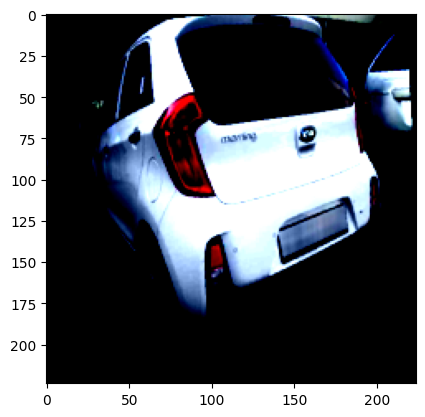

In [32]:
from matplotlib import pyplot as plt
plt.imshow(images[0].permute(1,2,0))
plt.show()

<h3>MODEL_1: CNN</h3>

In [16]:
class carClassifier(nn.Module):
    def __init__(self,num_class):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1),#(16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),#(16,112,112),
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),#(32,56,56)
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),#(64,28,28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_class)
        )
    def forward(self,x):
        x=self.network(x)
        return x

In [17]:
model=carClassifier(num_class=num_class)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=.001)

In [35]:
def train_model(model, criterion, optimizer, epochs=5):

    start = time.time()

    # Store best validation accuracy
    best_val_accuracy = 0.0

    for epoch in range(epochs):

        # ---------- Training ----------
        model.train()
        running_loss = 0.0

        for batch_num, (images, labels) in enumerate(train_loader):

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (batch_num + 1) % 10 == 0:
                print(
                    f"Batch: {batch_num + 1}, "
                    f"Epoch: {epoch + 1}, "
                    f"Loss: {loss.item():.2f}"
                )

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # ---------- Validation ----------
        model.eval()

        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                outputs = model(images)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()

                all_labels.extend(labels.numpy())
                all_predictions.extend(predicted.numpy())

        val_accuracy = 100 * correct / total

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Avg Loss: {epoch_loss:.4f}, "
            f"Validation Accuracy: {val_accuracy:.2f}%"
        )

        # ---------- Save Best Model ----------
        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            torch.save(
                model.state_dict(),
                "best_mobilenet_model.pth"
            )

            print(
                f"Best model saved! "
                f"Validation Accuracy: {best_val_accuracy:.2f}%"
            )

    # ---------- End ----------
    end = time.time()

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.2f}%"
    )

    print(
        f"Execution time: "
        f"{end - start:.2f} seconds"
    )

    return all_labels, all_predictions

In [19]:
all_labels,all_predictions=train_model(model,criterion,optimizer,epochs=5)

Batch: 10, Epoch: 1, Loss: 1.77
Batch: 20, Epoch: 1, Loss: 1.77
Batch: 30, Epoch: 1, Loss: 1.61
Batch: 40, Epoch: 1, Loss: 1.44
Batch: 50, Epoch: 1, Loss: 1.31
Epoch [1/5], Avg Loss: 1.8102, Validation Accuracy: 37.74%
Batch: 10, Epoch: 2, Loss: 1.51
Batch: 20, Epoch: 2, Loss: 1.17
Batch: 30, Epoch: 2, Loss: 1.32
Batch: 40, Epoch: 2, Loss: 1.06
Batch: 50, Epoch: 2, Loss: 1.27
Epoch [2/5], Avg Loss: 1.3276, Validation Accuracy: 48.35%
Batch: 10, Epoch: 3, Loss: 1.45
Batch: 20, Epoch: 3, Loss: 1.30
Batch: 30, Epoch: 3, Loss: 1.14
Batch: 40, Epoch: 3, Loss: 1.03
Batch: 50, Epoch: 3, Loss: 1.12
Epoch [3/5], Avg Loss: 1.1833, Validation Accuracy: 52.35%
Batch: 10, Epoch: 4, Loss: 1.34
Batch: 20, Epoch: 4, Loss: 1.02
Batch: 30, Epoch: 4, Loss: 1.08
Batch: 40, Epoch: 4, Loss: 0.83
Batch: 50, Epoch: 4, Loss: 0.92
Epoch [4/5], Avg Loss: 1.0915, Validation Accuracy: 52.52%
Batch: 10, Epoch: 5, Loss: 0.84
Batch: 20, Epoch: 5, Loss: 1.00
Batch: 30, Epoch: 5, Loss: 1.43
Batch: 40, Epoch: 5, Loss: 0

<h3>MODEL_2: CNN_with_regularization</h3>

In [20]:
class CarClassifierCNNWithRegularization(nn.Module):

    def __init__(self, num_class):
        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1),  # (16, 224, 224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),  # (16, 112, 112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1),  # (32, 112, 112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),  # (32, 56, 56)
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),  # (64, 56, 56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),  # (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_class)
        )
    def forward(self, x):
        x = self.network(x)
        return x

In [21]:
model=carClassifier(num_class=num_class)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=.001,weight_decay=1e-4)

train_model(model,criterion,optimizer,epochs=5)

Batch: 10, Epoch: 1, Loss: 1.81
Batch: 20, Epoch: 1, Loss: 1.72
Batch: 30, Epoch: 1, Loss: 1.69
Batch: 40, Epoch: 1, Loss: 1.80
Batch: 50, Epoch: 1, Loss: 1.49
Epoch [1/5], Avg Loss: 1.9063, Validation Accuracy: 33.04%
Batch: 10, Epoch: 2, Loss: 1.54
Batch: 20, Epoch: 2, Loss: 1.41
Batch: 30, Epoch: 2, Loss: 1.47
Batch: 40, Epoch: 2, Loss: 1.52
Batch: 50, Epoch: 2, Loss: 1.63
Epoch [2/5], Avg Loss: 1.4918, Validation Accuracy: 39.30%
Batch: 10, Epoch: 3, Loss: 1.24
Batch: 20, Epoch: 3, Loss: 1.60
Batch: 30, Epoch: 3, Loss: 1.13
Batch: 40, Epoch: 3, Loss: 1.29
Batch: 50, Epoch: 3, Loss: 1.40
Epoch [3/5], Avg Loss: 1.3797, Validation Accuracy: 41.39%
Batch: 10, Epoch: 4, Loss: 1.25
Batch: 20, Epoch: 4, Loss: 1.35
Batch: 30, Epoch: 4, Loss: 1.33
Batch: 40, Epoch: 4, Loss: 1.13
Batch: 50, Epoch: 4, Loss: 1.25
Epoch [4/5], Avg Loss: 1.3304, Validation Accuracy: 44.70%
Batch: 10, Epoch: 5, Loss: 1.37
Batch: 20, Epoch: 5, Loss: 1.38
Batch: 30, Epoch: 5, Loss: 1.45
Batch: 40, Epoch: 5, Loss: 1

([np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64

<h3>MODEL_3: CNN_with_transfer_learnings</h3>

In [22]:
from torchvision import models
model = models.efficientnet_b0(weights='DEFAULT' )
model.classifier[1].in_features

1280

In [23]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_class)
        )
    def forward(self, x):
        x = self.model(x)
        return x

In [24]:
model = CarClassifierEfficientNet(num_class=num_class)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1, Loss: 1.68
Batch: 20, Epoch: 1, Loss: 1.49
Batch: 30, Epoch: 1, Loss: 1.46
Batch: 40, Epoch: 1, Loss: 1.27
Batch: 50, Epoch: 1, Loss: 1.11
Epoch [1/5], Avg Loss: 1.4455, Validation Accuracy: 57.91%
Batch: 10, Epoch: 2, Loss: 1.13
Batch: 20, Epoch: 2, Loss: 1.10
Batch: 30, Epoch: 2, Loss: 1.23
Batch: 40, Epoch: 2, Loss: 1.11
Batch: 50, Epoch: 2, Loss: 1.22
Epoch [2/5], Avg Loss: 1.0884, Validation Accuracy: 65.39%
Batch: 10, Epoch: 3, Loss: 1.06
Batch: 20, Epoch: 3, Loss: 0.92
Batch: 30, Epoch: 3, Loss: 0.99
Batch: 40, Epoch: 3, Loss: 1.02
Batch: 50, Epoch: 3, Loss: 1.05
Epoch [3/5], Avg Loss: 0.9812, Validation Accuracy: 65.04%
Batch: 10, Epoch: 4, Loss: 1.04
Batch: 20, Epoch: 4, Loss: 0.96
Batch: 30, Epoch: 4, Loss: 0.95
Batch: 40, Epoch: 4, Loss: 1.03
Batch: 50, Epoch: 4, Loss: 0.98
Epoch [4/5], Avg Loss: 0.9208, Validation Accuracy: 65.74%
Batch: 10, Epoch: 5, Loss: 1.04
Batch: 20, Epoch: 5, Loss: 0.86
Batch: 30, Epoch: 5, Loss: 0.66
Batch: 40, Epoch: 5, Loss: 0

([np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64

<h3>MODEL_4: CNN_with_transfer_learnings(resnet)</h3>

In [25]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_class):
        super() .__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected Layer
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze Layer4 and fc Layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace the final fully connected Layer
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.model.fc.in_features, num_class)
        )
    def forward(self, x):
        x = self.model(x)
        return x

In [26]:
model = CarClassifierResNet(num_class=num_class)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1, Loss: 0.92
Batch: 20, Epoch: 1, Loss: 0.75
Batch: 30, Epoch: 1, Loss: 0.80
Batch: 40, Epoch: 1, Loss: 0.80
Batch: 50, Epoch: 1, Loss: 0.83
Epoch [1/5], Avg Loss: 0.8705, Validation Accuracy: 73.57%
Batch: 10, Epoch: 2, Loss: 0.49
Batch: 20, Epoch: 2, Loss: 0.57
Batch: 30, Epoch: 2, Loss: 0.57
Batch: 40, Epoch: 2, Loss: 0.33
Batch: 50, Epoch: 2, Loss: 0.29
Epoch [2/5], Avg Loss: 0.4970, Validation Accuracy: 76.87%
Batch: 10, Epoch: 3, Loss: 0.31
Batch: 20, Epoch: 3, Loss: 0.16
Batch: 30, Epoch: 3, Loss: 0.34
Batch: 40, Epoch: 3, Loss: 0.34
Batch: 50, Epoch: 3, Loss: 0.52
Epoch [3/5], Avg Loss: 0.3798, Validation Accuracy: 76.70%
Batch: 10, Epoch: 4, Loss: 0.36
Batch: 20, Epoch: 4, Loss: 0.13
Batch: 30, Epoch: 4, Loss: 0.11
Batch: 40, Epoch: 4, Loss: 0.16
Batch: 50, Epoch: 4, Loss: 0.32
Epoch [4/5], Avg Loss: 0.2639, Validation Accuracy: 80.70%
Batch: 10, Epoch: 5, Loss: 0.18
Batch: 20, Epoch: 5, Loss: 0.09
Batch: 30, Epoch: 5, Loss: 0.10
Batch: 40, Epoch: 5, Loss: 0

([np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64

#### I ran hyperparameter tunning in another notebook and figured that the best parameters for resnet models are (1) Dropout rate = 0.2 (2) Learning Rate = 0.005

So now let's train the model once again with these best parameters

In [31]:
model = CarClassifierResNet(num_class=num_class, dropout_rate=0.2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.005)
labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 0.98
Batch: 20, Epoch: 1, Loss: 0.71
Batch: 30, Epoch: 1, Loss: 0.95
Batch: 40, Epoch: 1, Loss: 0.60
Batch: 50, Epoch: 1, Loss: 0.55
Epoch [1/10], Avg Loss: 0.8822, Validation Accuracy: 66.43%
Batch: 10, Epoch: 2, Loss: 0.63
Batch: 20, Epoch: 2, Loss: 0.64
Batch: 30, Epoch: 2, Loss: 0.51
Batch: 40, Epoch: 2, Loss: 0.51
Batch: 50, Epoch: 2, Loss: 0.40
Epoch [2/10], Avg Loss: 0.5109, Validation Accuracy: 75.83%
Batch: 10, Epoch: 3, Loss: 0.51
Batch: 20, Epoch: 3, Loss: 0.65
Batch: 30, Epoch: 3, Loss: 0.50
Batch: 40, Epoch: 3, Loss: 0.29
Batch: 50, Epoch: 3, Loss: 0.19
Epoch [3/10], Avg Loss: 0.3720, Validation Accuracy: 74.96%
Batch: 10, Epoch: 4, Loss: 0.10
Batch: 20, Epoch: 4, Loss: 0.16
Batch: 30, Epoch: 4, Loss: 0.30
Batch: 40, Epoch: 4, Loss: 0.46
Batch: 50, Epoch: 4, Loss: 0.42
Epoch [4/10], Avg Loss: 0.3092, Validation Accuracy: 81.91%
Batch: 10, Epoch: 5, Loss: 0.06
Batch: 20, Epoch: 5, Loss: 0.10
Batch: 30, Epoch: 5, Loss: 0.22
Batch: 40, Epoch: 5, Los

### Model Evaluation using Confusion Matrix and Classification Report

In [32]:
from sklearn.metrics import classification_report
report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.78      0.81       111
           1       0.88      0.58      0.70       112
           2       0.66      0.96      0.78       128
           3       0.64      0.80      0.71        76
           4       0.77      0.45      0.56        74
           5       0.71      0.68      0.69        74

    accuracy                           0.73       575
   macro avg       0.75      0.71      0.71       575
weighted avg       0.75      0.73      0.72       575



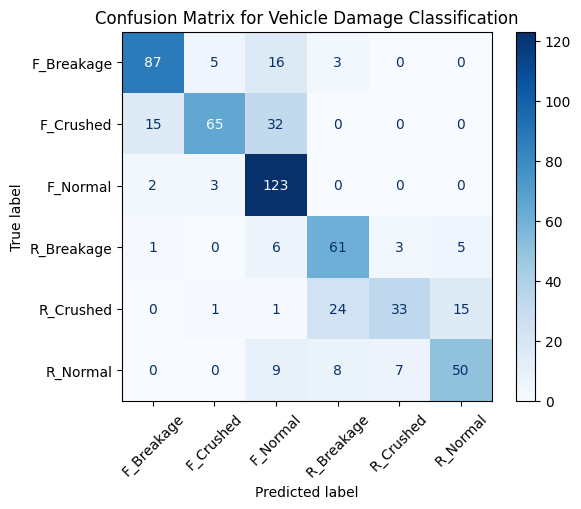

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_class))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

### Save the Model

In [38]:
torch.save(model.state_dict(), 'saved_model.pth')